1. Prima fase di conversione

In [1]:
# import json
# import ijson

# with open(r"path/to/my/file", "r") as infile, open("public_v2.ndjson", "w") as outfile:
#     for key, value in ijson.kvitems(infile, ''):
#         value["log_id"] = key
#         outfile.write(json.dumps(value) + "\n")

2. Lettura del file con DuckDB limitando il dataset alle prime mille righe

In [2]:
import duckdb
import pandas as pd

con = duckdb.connect()

df = con.execute("""
    SELECT *
    FROM read_json_auto('public_v2.ndjson')
    LIMIT 1000
""").df()

3. Inserimento anomalie artificiali

In [3]:
attacks = [
    {
        "referrer": "http://search.lib.auth.gr/Search/<script>alert('XSS')</script>",
        "request": "search.lib.auth.gr:80 185.22.12.44 - - [01/Mar/2018:00:00:15 +0200] GET /Search?q=<script>alert('XSS')</script> HTTP/1.1 400 1200 http://search.lib.auth.gr/Search/<script>alert('XSS')</script> Mozilla/5.0",
        "method": "GET",
        "resource": "/Search?q=<script>alert('XSS')</script>",
        "bytes": "1200",
        "response": "400",
        "ip": "185.22.12.44",
        "useragent": "Mozilla/5.0",
        "timestamp": "2018-02-28T22:00:15.000Z",
        "log_id": "attack_xss"
    },
    {
        "referrer": "http://evil.com",
        "request": "search.lib.auth.gr:80 45.77.88.12 - - [01/Mar/2018:00:00:20 +0200] GET /login?user=admin' OR 1=1-- HTTP/1.1 500 800 http://evil.com Mozilla/5.0",
        "method": "GET",
        "resource": "/login?user=admin' OR 1=1--",
        "bytes": "800",
        "response": "500",
        "ip": "45.77.88.12",
        "useragent": "Mozilla/5.0",
        "timestamp": "2018-02-28T22:00:20.000Z",
        "log_id": "attack_sql"
    },
    {
        "referrer": "-",
        "request": "search.lib.auth.gr:80 91.200.12.77 - - [01/Mar/2018:00:00:25 +0200] GET /../../../../etc/passwd HTTP/1.1 403 300 - curl/7.58.0",
        "method": "GET",
        "resource": "/../../../../etc/passwd",
        "bytes": "300",
        "response": "403",
        "ip": "91.200.12.77",
        "useragent": "curl/7.58.0",
        "timestamp": "2018-02-28T22:00:25.000Z",
        "log_id": "attack_traversal"
    },
    {
        "referrer": "-",
        "request": "search.lib.auth.gr:80 203.0.113.45 - - [01/Mar/2018:00:00:30 +0200] GET /wp-admin/install.php HTTP/1.1 404 250 - sqlmap/1.7",
        "method": "GET",
        "resource": "/wp-admin/install.php",
        "bytes": "250",
        "response": "404",
        "ip": "203.0.113.45",
        "useragent": "sqlmap/1.7",
        "timestamp": "2018-02-28T22:00:30.000Z",
        "log_id": "attack_scanner"
    }
]

df = pd.concat([df, pd.DataFrame(attacks)], ignore_index=True)


# conversione timestamp in formato coerente

df["timestamp"] = pd.to_datetime(df["timestamp"])

4. Ingegneria delle features

- 4.1 Lughezza della resource richiesta

In [4]:
df["resource_len"] = df["resource"].str.len()

- 4.2 Calcolo del range interquantilico sulla lunghezza delle risorsa

In [5]:
from detect import has_suspicious_request_len

df = has_suspicious_request_len(df)


- 4.3 Conteggio dei caratteri speciali

In [6]:
df["special_chars"] = df["request"].str.count(r"[<>\'\"%;(){}]*+@")

- 4.4 Ricerca della sequneza tipica del path traversal

In [7]:
df["has_traversal"] = df["request"].str.contains(r"\.\./", regex=True, na=False).astype(int)

- 4.5 Ricerca delle keywords tipiche delle SQLi

In [8]:
df["has_sql_keywords"] = df["request"].str.contains(
    r"union|select|insert|drop|or 1=1|--|admin",
    case=False,
    na=False
).astype(int)

- 4.6 Ricerca delle keywords tipiche dei tentativi di XSS

In [9]:
df["has_script_tag"] = df["request"].str.contains(
    r"<script>",
    case=False,
    na=False
).astype(int)

- 4.7 Ricerca degli scanner agent malevoli

In [10]:

df["scanner_agent"] = df["useragent"].str.contains(
    r"sqlmap|nikto|curl|nmap|dirbuster",
    case=False,
    na=False
).astype(int)


- 4.8 Ricerca degli errori

In [11]:
df["is_error"] = (df["response"].astype(int) >= 400).astype(int)

- 4.9 Conteggio delle query nella singola richiesta

In [12]:
df["num_params"] = df["resource"].str.count("=")

- 4.10 Numero di richieste per singolo IP

In [13]:
df["requests_per_ip"] = df.groupby("ip")["ip"].transform("count")

- 4.11 Calcolo dell'entropia di shannon della richiesta

In [14]:
from detect import entropy

df["request_entropy"] = df["request"].apply(lambda x: entropy(str(x)))

- 4.12 Calcolo del rapporto tra i byte trasferiti in una singola richiesta  e la media storica sulla stessa richiesta

In [15]:
df['bytes_num'] = pd.to_numeric(df['bytes'], errors='coerce').fillna(0)
resource_avg_bytes = df.groupby('resource')['bytes_num'].transform('mean')

df['bytes_ratio'] = df['bytes_num'] / (resource_avg_bytes + 1)


- 4.13 Ricerca dei bot benevoli adibiti al web crawling

In [16]:
bot_keywords = [
    'bot', 'crawler', 'spider', 'slurp', 'bingpreview', 'thumbshot',
    'bubing', 'dotbot', 'icc-crawler', 'googlebot', 'yandex', 'baidu',
    'bingbot', 'msnbot', 'adidxbot', 'applebot', 'teoma'
]
bot_pattern = '|'.join(bot_keywords)
df["is_known_bot"] = df["useragent"].str.contains(bot_pattern, case = False, na = False).astype(int)

IMPLEMENTAZIONE DELL'ALGORITMO DI ISOLATION FOREST
1. L'algoritmo non accetta stringhe o date. Dobbiamo isolare solo le colonne numeriche.


In [17]:
features_numeriche = [
    'resource_len', 'num_params', 'requests_per_ip', 'request_entropy', 'bytes_num',
    'bytes_ratio'
]

features_boolean = [
    'has_suspicious_request_len', 'special_chars',
    'has_traversal', 'has_sql_keywords', 'has_script_tag',
    'scanner_agent', 'is_error', 'is_known_bot'
]

features = features_numeriche+features_boolean

X = df[features]


- 1.1 Definizione dei parametri migliori

In [18]:
df['is_attack_real'] = df['log_id'].str.contains('attack').astype(int)
df.loc[df['is_attack_real'] == 1, 'is_attack_real'] = -1
df.loc[df['is_attack_real'] == 0, 'is_attack_real'] = 1

In [19]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, make_scorer
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


model = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
transformer = ColumnTransformer([
    ('numeric_cols', MinMaxScaler((0, 1)), features_numeriche)
])
prod_pipe = Pipeline([
    ('transformer', transformer),
    ('model', model)
])

params_grid = {
    "model__n_estimators": [100, 500, 1000, 1500, 2000],
    "model__contamination": [0.01, 0.015, 0.020, 0.025, 0.03]
}

score_grid = {'rec': 'recall_macro',  # vero positivo/(vero positivo+falso negativo)
              'pres': 'precision_macro'}  # vero positivo/(vero positivo+falso positivo)

prod_val = GridSearchCV(estimator=prod_pipe, cv=3, param_grid=params_grid, scoring=score_grid, refit='rec', n_jobs=-1, error_score=True).fit(X, df['is_attack_real'])
best_model = prod_val.best_estimator_
best_results = pd.DataFrame(prod_val.cv_results_)

f'Configurazione ottimale: {prod_val.best_params_}\nCV Recall: {prod_val.best_score_}'


"Configurazione ottimale: {'model__contamination': 0.01, 'model__n_estimators': 1000}\nCV Recall: 0.7896646101735922"

In [20]:
best_contamination = prod_val.best_params_["model__contamination"]
best_n_estimators = prod_val.best_params_["model__n_estimators"]

2. Configurazione e Addestramento
L'Isolation Forest funziona creando alberi decisionali casuali: le anomalie vengono "isolate" più velocemente.


In [21]:
model = IsolationForest(n_estimators=best_n_estimators, contamination=best_contamination, random_state=42)

# Addestramento
df['anomaly_score'] = model.fit_predict(X)

model
# Risultato: -1 significa Anomalia, 1 significa Traffico Normale

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",1000
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


3. Interpretazione dei risultati



In [22]:
# Punteggio grezzo: valori negativi = più anomalo
df['scores'] = model.decision_function(X)

# per vedere se gli attacchi sono stati classificati come tali
df[df['log_id'].str.contains('attack')][['log_id', 'anomaly_score', 'scores']]

,log_id,anomaly_score,scores
1000,attack_xss,-1,-0.077068
1001,attack_sql,-1,-0.115235
1002,attack_traversal,-1,-0.131732
1003,attack_scanner,-1,-0.144410


4. Verifica dei Falsi Positivi

In [23]:
# Mostra le 10 richieste più sospette del dataset
top_anomalies = df[df["anomaly_score"] == -1].sort_values(by='scores')
top_anomalies[['request','useragent','log_id', 'resource_len','has_suspicious_request_len', 'special_chars', 'has_traversal',
                    'has_sql_keywords', 'has_script_tag', 'scanner_agent', 'is_error',
                    'num_params', 'requests_per_ip', 'request_entropy', 'bytes_num',
                    'bytes_ratio', 'is_known_bot', 'is_attack_real', 'anomaly_score',
                    'scores']]

,request,useragent,log_id,resource_len,has_suspicious_request_len,special_chars,has_traversal,has_sql_keywords,has_script_tag,scanner_agent,is_error,num_params,requests_per_ip,request_entropy,bytes_num,bytes_ratio,is_known_bot,is_attack_real,anomaly_score,scores
1003,search.lib.auth.gr:80 203.0.113.45 - - [01/Mar...,sqlmap/1.7,attack_scanner,21,1,0,0,1,0,1,1,0,1,4.795299,250,0.996016,0,-1,-1,-0.144410
1002,search.lib.auth.gr:80 91.200.12.77 - - [01/Mar...,curl/7.58.0,attack_traversal,23,1,0,1,0,0,1,1,0,1,4.569546,300,0.996678,0,-1,-1,-0.131732
1001,search.lib.auth.gr:80 45.77.88.12 - - [01/Mar/...,Mozilla/5.0,attack_sql,27,1,0,0,1,0,0,1,2,1,4.966076,800,0.998752,0,-1,-1,-0.115235
826,search.lib.auth.gr:80 176.92.34367 - - [01/Mar...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,xbRfsmoBCue8G08E0FlG,359,1,0,0,0,0,0,0,6,186,5.551575,678,0.998527,0,1,-1,-0.113653
1000,search.lib.auth.gr:80 185.22.12.44 - - [01/Mar...,Mozilla/5.0,attack_xss,39,1,0,0,0,1,0,1,1,1,5.028478,1200,0.999167,0,-1,-1,-0.077068
629,search.lib.auth.gr:80 155.207.36594 - - [01/Ma...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,hLRfsmoBCue8G08E0VpD,188,1,0,0,0,0,0,0,6,82,5.507627,677,0.998525,0,1,-1,-0.064807
918,search.lib.auth.gr:80 176.92.34367 - - [01/Mar...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WrRfsmoBCue8G08Ez1ki,418,1,0,0,0,0,0,0,4,186,5.335568,677,0.998525,0,1,-1,-0.057681
766,search.lib.auth.gr:80 202.180.35500 - - [01/Ma...,ICC-Crawler/2.0 (Mozilla-compatible; ; http://...,_bRfsmoBCue8G08E0FlY,126,1,0,0,0,0,0,0,3,70,5.247395,2724,0.999633,1,1,-1,-0.031828
734,search.lib.auth.gr:80 202.180.35500 - - [01/Ma...,ICC-Crawler/2.0 (Mozilla-compatible; ; http://...,HLRfsmoBCue8G08E0FpY,83,0,0,0,0,0,0,0,0,70,5.199108,115984,0.999991,1,1,-1,-0.018313
327,search.lib.auth.gr:80 85.74.35922 - - [01/Mar/...,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:5...,trRfsmoBCue8G08E01sU,61,0,0,0,0,0,0,0,1,30,5.216393,65714,0.999982,0,1,-1,-0.005609


- 4.1 Esplorazione dei falsi positivi

In [24]:
top_anomalies_melted = top_anomalies.melt(
    id_vars='log_id',
    var_name='categories',
    value_vars=features_boolean,
    value_name='value'
)
# top_anomalies_melted.groupby("categories")["value"].sum()
active = top_anomalies_melted[top_anomalies_melted["value"] == 1]
combos = active.groupby("log_id")["categories"].agg(lambda x: ", ".join(tuple(sorted(x)))).reset_index(name='tuple')

combos["tuple"].value_counts()

tuple
has_suspicious_request_len                                               3
is_known_bot                                                             1
has_suspicious_request_len, is_known_bot                                 1
has_sql_keywords, has_suspicious_request_len, is_error, scanner_agent    1
has_sql_keywords, has_suspicious_request_len, is_error                   1
has_suspicious_request_len, has_traversal, is_error, scanner_agent       1
has_script_tag, has_suspicious_request_len, is_error                     1
Name: count, dtype: int64

Dato che ho inserito degli attacchi manualmente (attack_xss, attack_sql, ecc.), posso calcolare una Matrice di Confusione semplificata per dimostrare se l'algoritmo è efficace nel trovare i record che ho nascosto io.


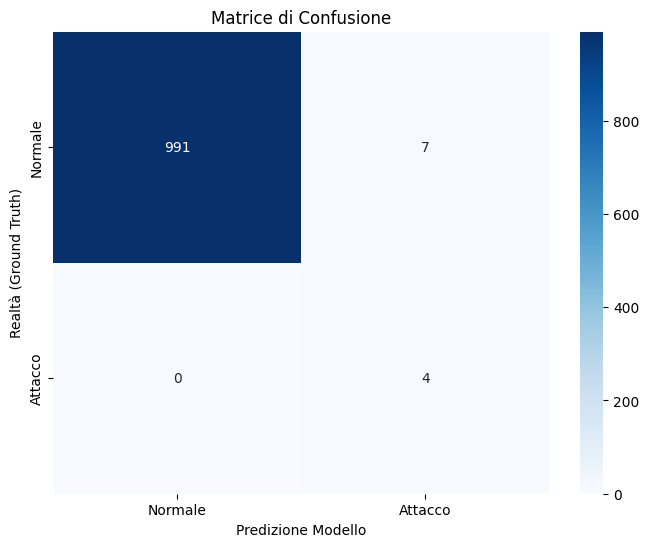

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report



df['is_attack_real'] = df['log_id'].str.contains('attack').astype(int)

df['is_attack_predicted'] = df['anomaly_score'].apply(lambda x: 1 if x == -1 else 0)

cm = confusion_matrix(df['is_attack_real'], df['is_attack_predicted'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normale', 'Attacco'],
            yticklabels=['Normale', 'Attacco'])
plt.xlabel('Predizione Modello')
plt.ylabel('Realtà (Ground Truth)')
plt.title('Matrice di Confusione')
plt.show()


Classification report

In [26]:
print(classification_report(df['is_attack_real'], df['is_attack_predicted']))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       998
           1       0.36      1.00      0.53         4

    accuracy                           0.99      1002
   macro avg       0.68      1.00      0.76      1002
weighted avg       1.00      0.99      0.99      1002



Punteggio associato dall'algoritmo ai singoli attacchi inseriti

In [27]:
test_attacks = df[df['log_id'].str.contains('attack')]
test_attacks[['log_id', 'anomaly_score', 'scores']]

,log_id,anomaly_score,scores
1000,attack_xss,-1,-0.077068
1001,attack_sql,-1,-0.115235
1002,attack_traversal,-1,-0.131732
1003,attack_scanner,-1,-0.144410


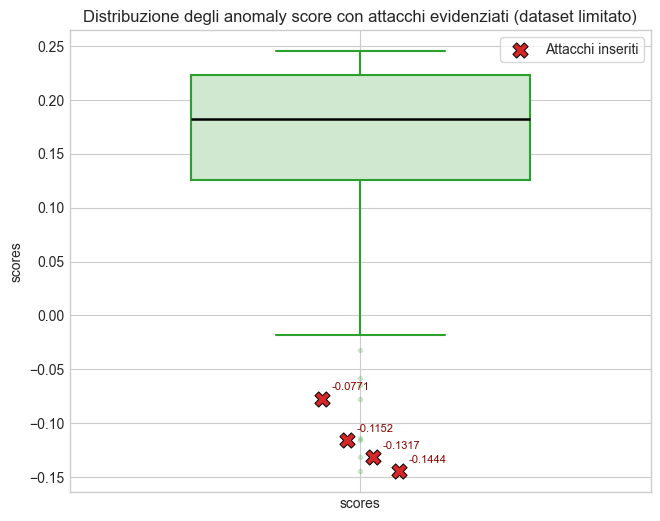

In [29]:
import numpy as np
import matplotlib.pyplot as plt

boxplot_data = df.copy()

score_value_attacchi_artificiali = boxplot_data[boxplot_data["log_id"].str.contains("attack", case = False)]["scores"].tolist()

if "tipo" not in boxplot_data.columns:
    if "log_id" in boxplot_data.columns:
        boxplot_data["tipo"] = np.where(
            boxplot_data["log_id"].astype(str).str.contains("attack", case=False, na=False),
            "Attacco inserito",
            "Normale"
        )
    else:
        boxplot_data["tipo"] = "Normale"

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(7.5, 6))

ax.boxplot(
    boxplot_data["scores"],
    vert=True,
    widths=0.35,
    patch_artist=True,
    showfliers=True,
    boxprops=dict(facecolor="#cfe8cf", color="#2ca02c", linewidth=1.5),
    whiskerprops=dict(color="#2ca02c", linewidth=1.5),
    capprops=dict(color="#2ca02c", linewidth=1.5),
    medianprops=dict(color="black", linewidth=1.8),
    flierprops=dict(
        marker="o",
        markerfacecolor="#2ca02c",
        markeredgecolor="#2ca02c",
        markersize=3,
        alpha=0.18
    )
)

x_attack = np.ones(len(score_value_attacchi_artificiali)) + np.linspace(-0.04, 0.04, len(score_value_attacchi_artificiali))
ax.scatter(
    x_attack,
    score_value_attacchi_artificiali,
    s=120,
    marker="X",
    color="#d62728",
    edgecolors="black",
    linewidths=0.7,
    zorder=5,
    label="Attacchi inseriti"
)

for i, s in enumerate(score_value_attacchi_artificiali):
    ax.annotate(
        f"{s:.4f}",
        (x_attack[i], s),
        textcoords="offset points",
        xytext=(7, 6),
        fontsize=8,
        color="darkred"
    )

ax.set_xticks([1])
ax.set_xticklabels(["scores"])
ax.set_ylabel("scores")
ax.set_title("Distribuzione degli anomaly score con attacchi evidenziati (dataset limitato)")
ax.legend(loc="upper right", frameon=True)
ax.set_xlim(0.7, 1.3)

plt.show()